In [1]:
import Pkg
Pkg.activate("/home/matteo/Projects/diffusion_inference/")

  Activating project at `~/Projects/diffusion_inference`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, PyPlot, LinearAlgebra, Statistics, JLD2

In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x, y, d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [24]:
@load "test3_A_save.jld2"

d, nsamples, T = size(x)

┌ Warning: Opening file with JLD2.MmapIO failed, falling back to IOStream
└ @ JLD2 ~/.julia/packages/JLD2/twZ5D/src/JLD2.jl:298


LoadError: LoadError: SystemError: opening file "test3_D_save.jld2": No such file or directory
in expression starting at In[24]:1

In [ ]:
d = 10
nsamples = 10_000
T = 50

In [ ]:
M = randn(d,d) * 1.2
J = M * M'

In [ ]:
eigen(inv(J)).values

In [ ]:
J = inv(inv(J) + 10.0*I(d))

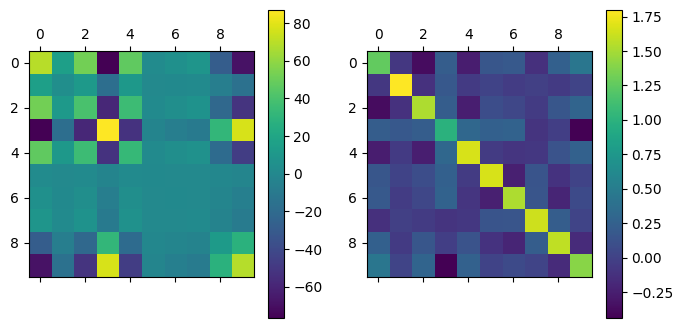

PyObject <matplotlib.colorbar.Colorbar object at 0x757647922cb0>

In [23]:
fig, ax = subplots(1,2,4)

ax[1].matshow(inv(J)) |> colorbar
ax[2].matshow(J) |> colorbar

In [ ]:
θ0 = zeros(d)
θ1 = 3.0 * randn(d)
θ = θ0 .+ (θ1 .* randn(d))
θ |> norm

In [ ]:
γ = 1.9

In [ ]:
x = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T);

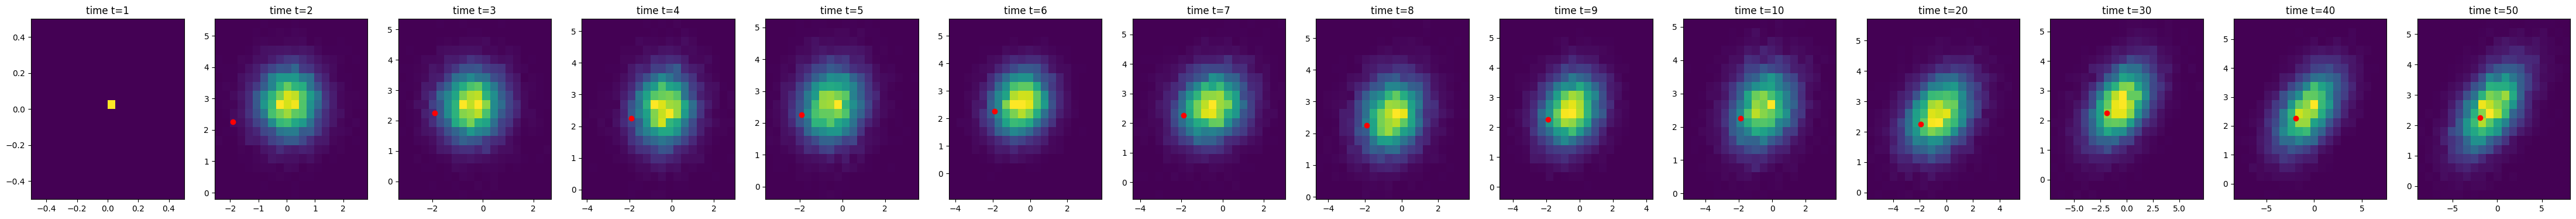

In [7]:
tpoints = [1,2,3,4,5,6,7,8,9,10,20,30,40,50]
fig, ax = subplots(1, length(tpoints), 4)
for t in eachindex(tpoints)
    ax[t].hist2d(x[1,:,tpoints[t]], x[2,:,tpoints[t]], bins=20)
    ax[t].scatter(θ[1], θ[2], marker="o", color="red")
    ax[t].set_title("time t=$(tpoints[t])")
end

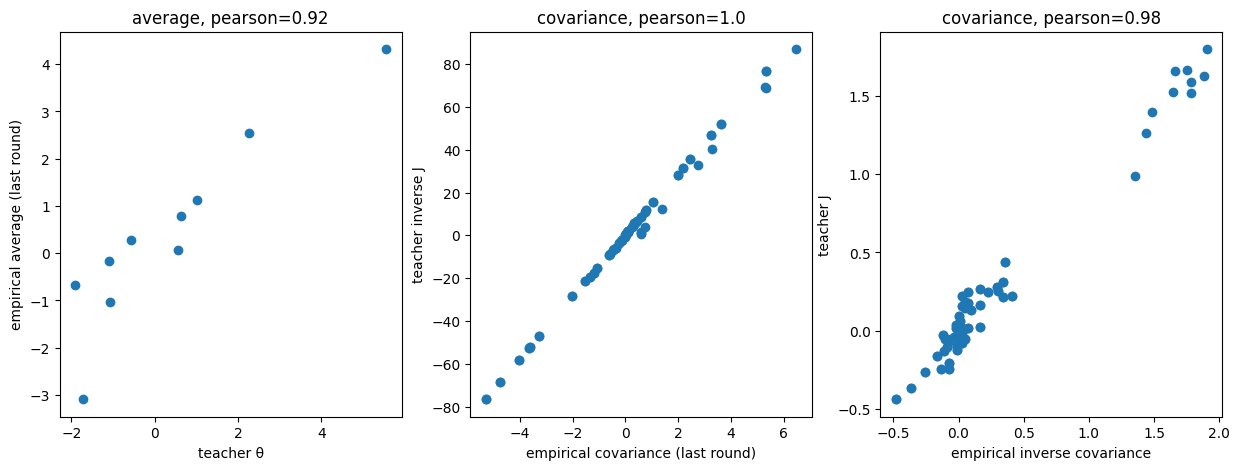

PyObject Text(0.5, 1.0, 'covariance, pearson=0.98')

In [11]:
fig, ax = subplots(1,3,5)
μ_eq = mean(x[:,:,end], dims=2)
Σ_eq = ((x[:,:,end] .- μ_eq)*(x[:,:,end] .- μ_eq)')./nsamples
#Σ_eq ./= sqrt.(diag(Σ_eq)) * sqrt.(diag(Σ_eq))'

ax[1].scatter(θ, μ_eq)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_eq))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_eq), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_eq), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_eq)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_eq)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [12]:
t_sample=[1, 2, 3, 4, 5,15]

6-element Vector{Int64}:
  1
  2
  3
  4
  5
 15

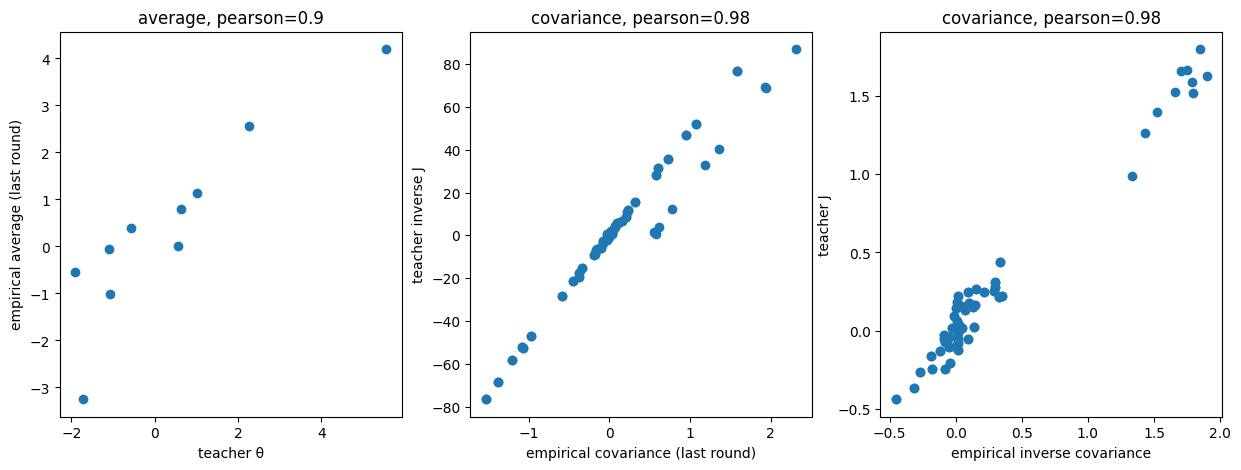

PyObject Text(0.5, 1.0, 'covariance, pearson=0.98')

In [13]:
fig, ax = subplots(1,3,5)
μ_last = mean(x[:,:,t_sample[end]], dims=2)
Σ_last = ((x[:,:,t_sample[end]] .- μ_eq)*(x[:,:,t_sample[end]] .- μ_eq)')./nsamples
#Σ_last ./= sqrt.(diag(Σ_last)) * sqrt.(diag(Σ_last))'

ax[1].scatter(θ, μ_last)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_last))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_last), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_last), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_last)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_last)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [16]:
counts = ones(nsamples, length(t_sample)) ./ nsamples
time = [1,2,3,4,5,15]
data = collect_data(zeros(d), x[:,:,t_sample], counts, time);

In [ ]:
λ = 0.0
prior = 0.01
ftol_rel = 1e-7

In [ ]:
results = learn_gamma_nlopt(data, initialize=5, λ=λ, prior=prior, ftol_rel=ftol_rel, rescale=false)

In [14]:
results.minx[end]

5.087854444628315

In [17]:
J_inferred = de.compute_J(results.minx, data.d);
θ_inferred = de.compute_theta(results.minx, data.d);

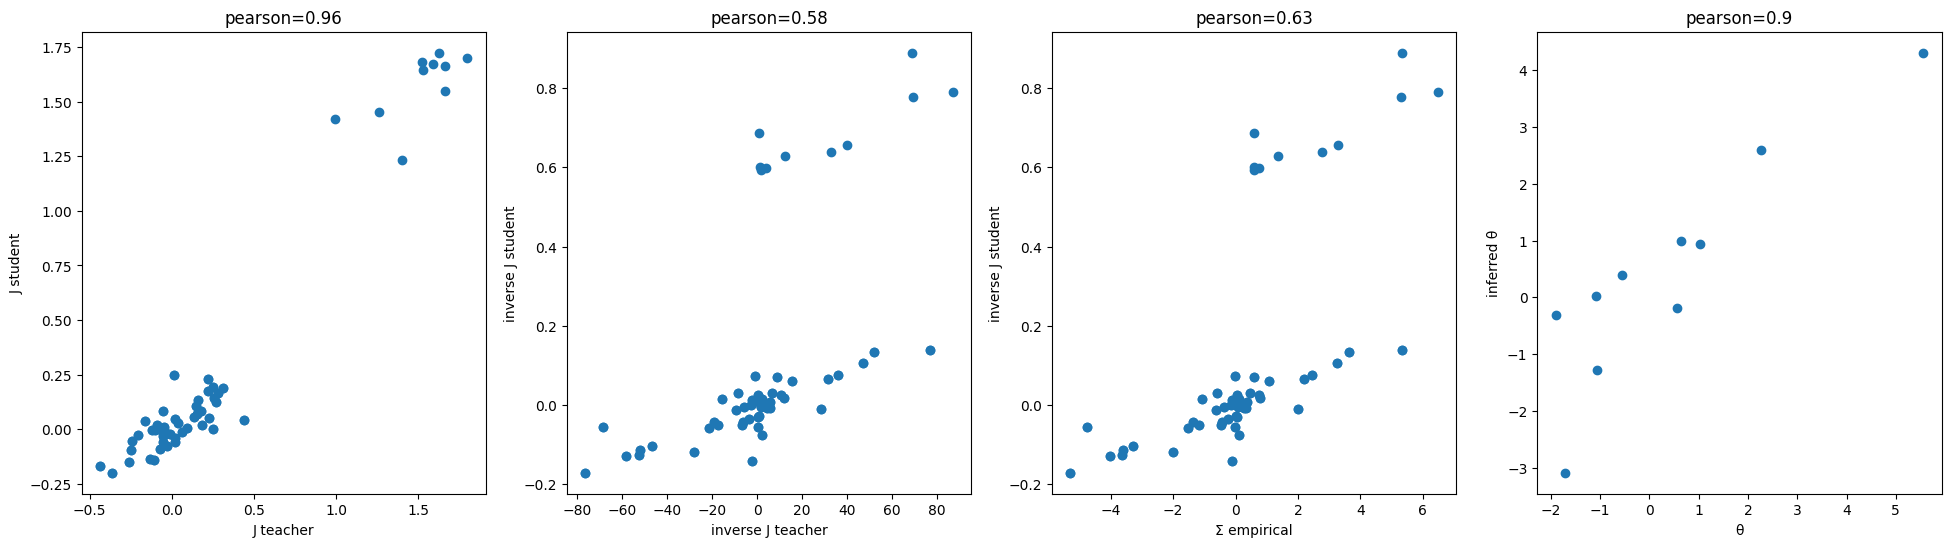

PyObject Text(0.5, 1.0, 'pearson=0.9')

In [18]:
fig, ax = subplots(1, 4, 6)
ax[1].scatter(J, J_inferred)
rho_J = cor(vec(J), vec(J_inferred))
ax[1].set_xlabel("J teacher")
ax[1].set_ylabel("J student")
ax[1].set_title("pearson=$(round(rho_J, digits=2))")

ax[2].scatter(inv(J), inv(J_inferred))
rho_invJ = cor(vec(inv(J)), vec(inv(J_inferred)))
ax[2].set_xlabel("inverse J teacher")
ax[2].set_ylabel("inverse J student")
ax[2].set_title("pearson=$(round(rho_invJ, digits=2))")

ax[3].scatter(Σ_eq, inv(J_inferred))
rho_sigma_invJ = cor(vec(Σ_eq), vec(inv(J_inferred)))
ax[3].set_xlabel("Σ empirical")
ax[3].set_ylabel("inverse J student")
ax[3].set_title("pearson=$(round(rho_sigma_invJ, digits=2))")

ax[4].scatter(θ, θ_inferred)
rho_theta = cor(vec(θ), θ_inferred)
ax[4].set_xlabel("θ")
ax[4].set_ylabel("inferred θ")
ax[4].set_title("pearson=$(round(rho_theta, digits=2))")

In [ ]:
γ = collect(0.1:0.1:10.0)

In [ ]:
lγ = map(x->de.log_likelihood(results.minx[1:end-1], data, x, λ, prior), γ)

In [ ]:
plot(γ, lγ .- (minimum(lγ) - 1.0), linestyle="dashed", marker="o", markersize=2)
#xscale(:log)
yscale(:log)

In [ ]:
@save "test3_B_save.jld2" J θ x results λ prior ftol_rel t_sample γ

# gamma grid

In [ ]:
γ_values = collect(0.1:0.1:1.0)

In [ ]:
results = Vector{Any}(undef, length(γ_values));

In [ ]:
λ_γ = 0.2

In [ ]:
for k in eachindex(γ_values)
    results[k] = learn_nlopt(data, initialize=2, λ=λ_γ, prior=prior, ftol_rel=ftol_rel, rescale=false, γ=γ_values[k])
    println(k,"/",length(γ_values))
end

In [ ]:
converged = map(x -> isa(x[1], Float64), results)

In [ ]:
#@save "test3_B_grid_save.jld2" results γ_values

In [ ]:
plot(γ_values[converged], map(x -> x[1],results[converged]))
#yscale(:log)